In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from skyfield.api import load, wgs84
from skyfield import almanac
from datetime import datetime, timedelta
import astropy
from skyfield.framelib import ecliptic_frame
from astropy.coordinates import SkyCoord, EarthLocation, AltAz, get_sun, get_body
from astropy.time import Time
import datetime
import astropy.units as u
from astroquery.simbad import Simbad
from astroplan import Observer, FixedTarget
from astropy.visualization import astropy_mpl_style, quantity_support

In [15]:
eph = load('de440s.bsp')
ephemeris = eph 
#Using the de440s emphemeris file for the locations

bodies = {
    "sun": eph['sun'],
    "moon": eph['moon'],
    "pluto": eph['pluto barycenter'],
    "mars": eph['mars barycenter'],
    "jupiter": eph['jupiter barycenter'],
    "saturn": eph['saturn barycenter'],
    "uranus": eph['uranus barycenter'],
    "venus": eph['venus barycenter'],
    "mercury": eph['mercury barycenter'],
    "neptune": eph['neptune barycenter'],
}
#Grabbing the planets from the emphemeris and naming them
sun = eph['sun']
earth = eph['earth']

ts = load.timescale()
#Skyfield's time system
days = np.arange(0, 90)
t_variable = ts.utc(2026, 3, 1 + days)
t_start = ts.utc(2026, 3, 1)
t_end = ts.utc(2026, 3, 1 + 90)
global t_variable

now = Time.now()
days =np.linspace(0, 90, 24*91)
times = now + days * u.day
#making time array thing

#altaz_frames = AltAz(obstime=times, location=columbus)
#getting altaz from times


columbus_lat = 39.9612
columbus_lon = -83.0003
columbus_elev = 260
#Location of Columbus, Ohio (observation point for our code)

columbus = earth + wgs84.latlon(columbus_lat, columbus_lon, elevation_m = columbus_elev)
#Creating the observer to call from


def is_planet_in_sky(self, t0, t1):
    #t0 is the start time, t1 is the end time of observation
    t, y = almanac.find_risings(columbus, self, t0, t1)



def moon_phase():

    
    percent_illuminated = 100 * columbus.at(t_variable).observe(eph['moon']).fraction_illuminated(eph['sun'])
    
    _, sunlong, _ = columbus.at(t_variable).observe(eph['sun']).apparent().frame_latlon(ecliptic_frame)
    _, moonlong, _ = columbus.at(t_variable).observe(eph['moon']).apparent().frame_latlon(ecliptic_frame)
    phase = (np.asarray(moonlong.degrees) - np.asarray(sunlong.degrees)) % 360
    illumination = np.asarray(percent_illuminated)

    conditions = [
        (phase >= 2) & (phase <= 88),
        (phase > 88) & (phase < 92),
        (phase >= 92) & (phase <= 178),
        (phase > 178) & (phase < 182),
        (phase >= 182) & (phase <= 268),
        (phase > 268) & (phase < 272),
        (phase >= 272) & (phase <= 358),
    ]
    labels = [
        'Waxing Crescent',
        'First Quarter',
        'Waxing Gibbous',
        'Full Moon',
        'Waning Gibbous',
        'Last Quarter',
        'Waning Crescent',
    ]
    phase_name = np.select(conditions, labels, default='New Moon')

    moon_df = pd.DataFrame({
        'percent_illuminated': illumination,
        'phase_angle_deg': phase,
        'moon_phase': phase_name,
    })
    return moon_df

moon_phases_df = moon_phase()




def observation_from_user(body, planet_name):

    astrometric = columbus.at(t_variable).observe(body)
    apparent = astrometric.apparent()
    alt, az, distance = apparent.altaz(pressure_mbar=1010)
    t, y = almanac.find_risings(columbus, body, t_start, t_end)
    t, y = almanac.find_settings(columbus, body, t_start, t_end)
    n = len(alt.degrees)
    df = pd.DataFrame({
        'Planet': [planet_name] * n,
        'Altitude': alt.degrees,
        'Azimuth': az.degrees,
    })
    return(df)


for planet_name, body in bodies.items():
    df = observation_from_user(body, planet_name)
    print(planet_name)
    print(df)


##find the Moon phase, locations of planets and determine if they are in the sky during astronomical twilight
# for moon:
#   phase = almanac.moon_phase(eph, t) -> t is time, eph is the emphemeris
# For moonrise:
#   t, y = almanac.find_risings(observer, moon, t0, t1)
#   print('Moonrises (UTC):', t.utc_iso(' '))

#   t, y = almanac.find_settings(observer, moon, t0, t1)
#   print('Moonsets (UTC):', t.utc_iso(' '))
#
# for other planets:
#   t, y = almanac.find_risings(observer, eph['Mars'], t0, t1)
# #print('Mars rises:', t.utc_iso(' '))
#   t, y = almanac.find_settings(observer, eph['Mars'], t0, t1)
#   print('Mars sets: ', t.utc_iso(' '))
#       eph['Mars'] is just mars in this case, and t0 and t1 are the timeframes


sun
   Planet  Altitude     Azimuth
0     sun -7.898333  266.589970
1     sun -7.694094  266.917544
2     sun -7.490169  267.247509
3     sun -7.286553  267.579736
4     sun -7.083238  267.914095
..    ...       ...         ...
85    sun  7.604270  290.973830
86    sun  7.736564  291.095538
87    sun  7.866274  291.211480
88    sun  7.993338  291.321636
89    sun  8.117696  291.425988

[90 rows x 3 columns]
moon
   Planet   Altitude     Azimuth
0    moon  37.658551   94.651433
1    moon  24.917090   91.325606
2    moon  12.340834   88.816370
3    moon   0.023945   86.679959
4    moon -11.976656   84.643083
..    ...        ...         ...
85   moon  49.371147  159.960974
86   moon  40.279316  149.013548
87   moon  30.644408  140.934404
88   moon  20.822171  134.429427
89   moon  10.983689  128.743326

[90 rows x 3 columns]
pluto
   Planet   Altitude     Azimuth
0   pluto -43.150124  275.185437
1   pluto -43.877671  275.871835
2   pluto -44.604569  276.568688
3   pluto -45.330698  277.2

# <b> Graphs For Streamlit

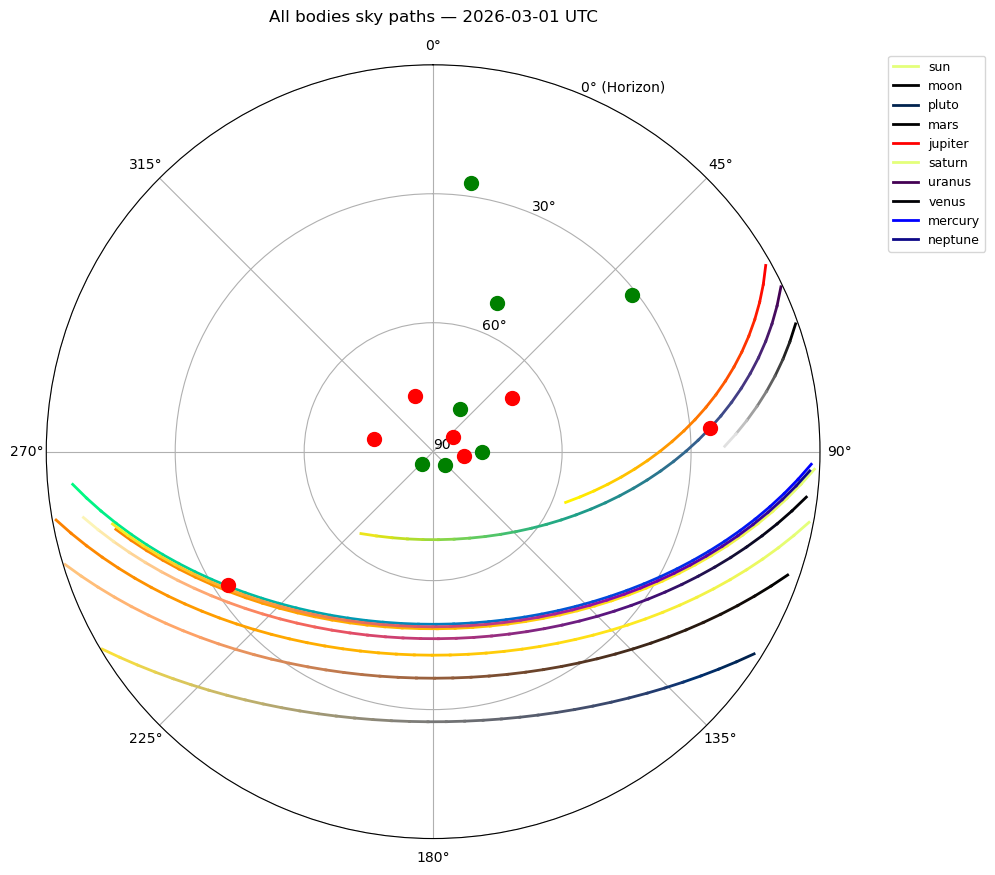

2026-03-01: 960 rows


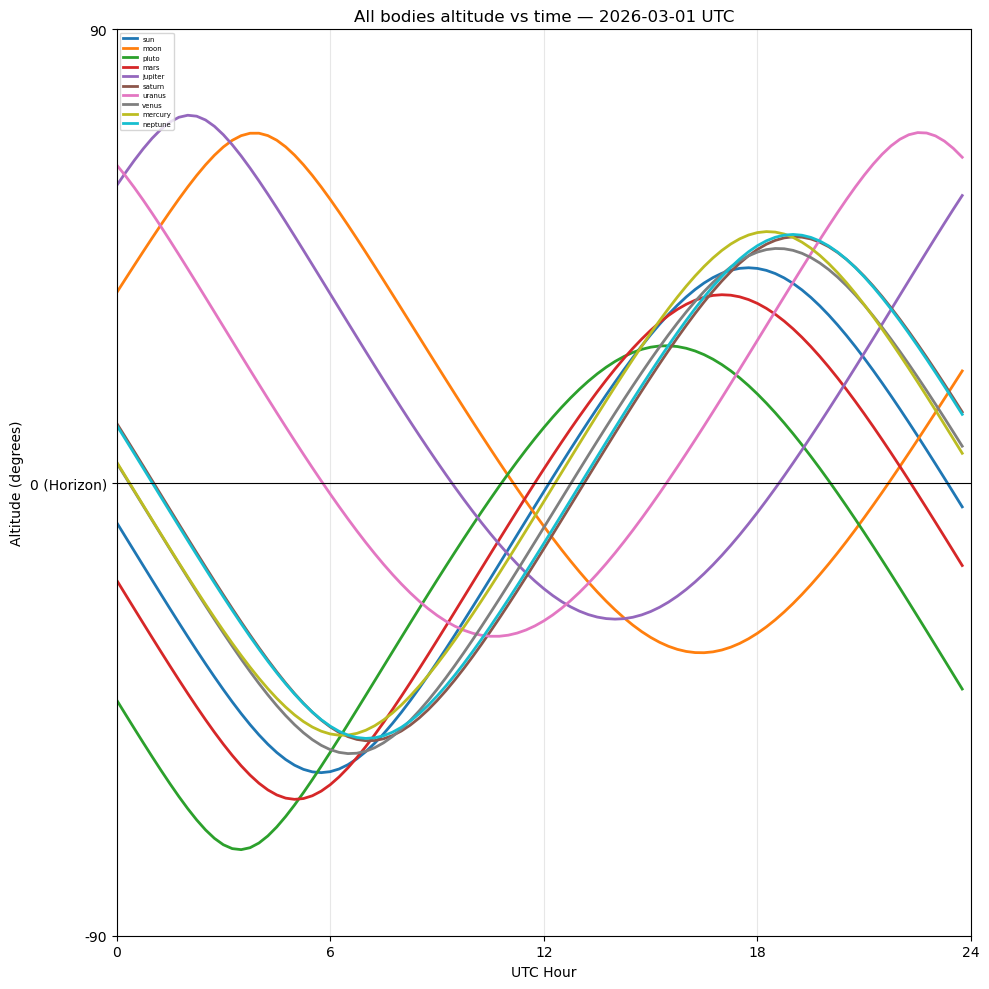

2026-03-01: 960 rows


In [16]:
#Singular day calculations
single_day = Time.now()
global single_day

def is_night():
    night_check = almanac.dark_twilight_day(eph, columbus_topos)
    night_state = night_check(single_day)
    return night_state <= 1

planet_cmaps = {
    "sun": "Wistia",
    "moon": "gray",
    "mercury": "winter",
    "venus": "magma",
    "mars": "copper",
    "jupiter": "autumn",
    "saturn": "Wistia",
    "uranus": "viridis",
    "neptune": "plasma",
    "pluto": "cividis",
}
cmap = plt.get_cmap(planet_cmaps.get(planet_name, "viridis"))

# Daily polar sky paths — run after the setup cell (needs `columbus`, `bodies`, `ts`).
N_SAMPLES_PER_DAY = 96  # samples from 0–24h UTC
def plot_all_planets_sky_path(year, month, day, n_samples=N_SAMPLES_PER_DAY):
    hours = np.linspace(0, 24, n_samples, endpoint=False)
    t_day = ts.utc(year, month, day, hours, 0)
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection='polar')
    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)
    ax.set_rlim(0, 90)
    ax.set_yticks(range(0, 91, 30))
    ax.set_yticklabels(['90°', '60°', '30°', '0° (Horizon)'])

    tab = plt.cm.tab10(np.linspace(0, 1, max(10, len(bodies))))
    dfs = []
    for idx, (planet_name, body) in enumerate(bodies.items()):
        astrometric = columbus.at(t_day).observe(body)
        alt, az, _ = astrometric.apparent().altaz(pressure_mbar=1010)
        altd = np.asarray(alt.degrees)
        azdeg = np.asarray(az.degrees)
        n = len(altd)
        dfs.append(
            pd.DataFrame(
                {
                    'Planet': [planet_name] * n,
                    'Altitude': altd,
                    'Azimuth': azdeg,
                }
            )
        )
        mask = altd > 0
        if np.any(mask):
            # Same tab10 color as plot_all_planets_altitude_vs_time for this planet
            color = tab[idx % len(tab)]
            mask_idx = np.where(mask)[0]
            # Split where visibility is not contiguous, so we do not draw
            # straight jump lines across below-horizon gaps.
            breaks = np.where(np.diff(mask_idx) > 1)[0] + 1
            chunks = np.split(mask_idx, breaks)

            legend_done = False
            az_rad = np.asarray(az.radians)
            for chunk in chunks:
                theta_chunk = az_rad[chunk]
                r_chunk = 90 - altd[chunk]

                # Handle Azimuth wrapping (0 <-> 360) to prevent cross-chart streaks
                wrap_breaks = np.where(np.abs(np.diff(theta_chunk)) > np.pi)[0] + 1
                theta_sub_chunks = np.split(theta_chunk, wrap_breaks)
                r_sub_chunks = np.split(r_chunk, wrap_breaks)

                for th, rr in zip(theta_sub_chunks, r_sub_chunks):
                    if len(th) < 2:
                        ax.plot(
                            th,
                            rr,
                            color=color,
                            marker='o',
                            markersize=3,
                            label=planet_name if not legend_done else None,
                        )
                    else:
                        ax.plot(
                            th,
                            rr,
                            color=color,
                            linewidth=2,
                            label=planet_name if not legend_done else None,
                        )
                    legend_done = True

    ax.legend(loc='upper left', bbox_to_anchor=(1.08, 1.02), fontsize=9)
    ax.set_title(f'All bodies sky paths — {year}-{month:02d}-{day:02d} UTC', pad=12)
    plt.tight_layout()
    plt.show()
    return pd.concat(dfs, ignore_index=True)
    
    # Add every UTC day you want; each gets one figure and one entry in the dict.
DAYS_UTC = [
    (2026, 3, 1),
]
sky_path_df_by_day = {}
for y, m, d in DAYS_UTC:
    day_key = f"{y}-{m:02d}-{d:02d}"
    df_day = plot_all_planets_sky_path(y, m, d)
    sky_path_df_by_day[day_key] = df_day.assign(UTC_date=day_key)
for day_key, df_day in sky_path_df_by_day.items():
    print(f"{day_key}: {len(df_day)} rows")

N_SAMPLES_PER_DAY = 96  # samples from 0–24h UTC
def plot_all_planets_altitude_vs_time(year, month, day, n_samples=N_SAMPLES_PER_DAY):
    hours = np.linspace(0, 24, n_samples, endpoint=False)
    # Skyfield time array for each UTC hour
    # If this ever complains about float hours, use the t0 + seconds approach below instead.
    t_day = ts.utc(year, month, day, hours, 0)
    # t0 = ts.utc(year, month, day, 0, 0, 0)
    # t_day = t0 + hours * 3600
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111)
    tab = plt.cm.tab10(np.linspace(0, 1, max(10, len(bodies))))
    dfs = []
    for idx, (planet_name, body) in enumerate(bodies.items()):
        astrometric = columbus.at(t_day).observe(body)
        alt, az, _ = astrometric.apparent().altaz(pressure_mbar=1010)
        altd = np.asarray(alt.degrees)
        azdeg = np.asarray(az.degrees)
        color = tab[idx % len(tab)]
        # Plot the full diurnal arc (negative altitude = below the horizon).
        ax.plot(hours, altd, color=color, linewidth=2, label=planet_name)
        n = len(altd)
        dfs.append(
            pd.DataFrame(
                {
                    "Planet": [planet_name] * n,
                    "UTC_hour": hours,
                    "Altitude": altd,
                    "Azimuth": azdeg,
                }
            )
        )
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xlim(0, 24)
    ax.set_ylim(-90, 90)
    ax.set_xlabel("UTC Hour")
    ax.set_ylabel("Altitude (degrees)")
    ax.set_title(f"All bodies altitude vs time — {year}-{month:02d}-{day:02d} UTC")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper left", fontsize=5)
    ax.set_xticks([0, 6, 12, 18, 24])
    ax.set_xticklabels([0, 6, 12, 18, 24])
    ax.set_yticks((-90, 0, 90))
    ax.set_yticklabels([-90, '0 (Horizon)', 90])
    
    plt.tight_layout()
    plt.show()
    return pd.concat(dfs, ignore_index=True)
DAYS_UTC = [
    (2026, 3, 1),
]
sky_path_df_by_day = {}
for y, m, d in DAYS_UTC:
    day_key = f"{y}-{m:02d}-{d:02d}"
    df_day = plot_all_planets_altitude_vs_time(y, m, d)
    sky_path_df_by_day[day_key] = df_day.assign(UTC_date=day_key)
for day_key, df_day in sky_path_df_by_day.items():
    print(f"{day_key}: {len(df_day)} rows")



# <b> My Attempt at Conjunctions

Searching for Mars-Jupiter conjunctions...
Period: 2026-03-01 to 2026-03-31
Computing separations at 31 daily intervals...

Separation analysis:
  Minimum: 113.38°
  Maximum: 136.51°
  Mean: 124.70°

No close approaches found (all separations > 10.0°)


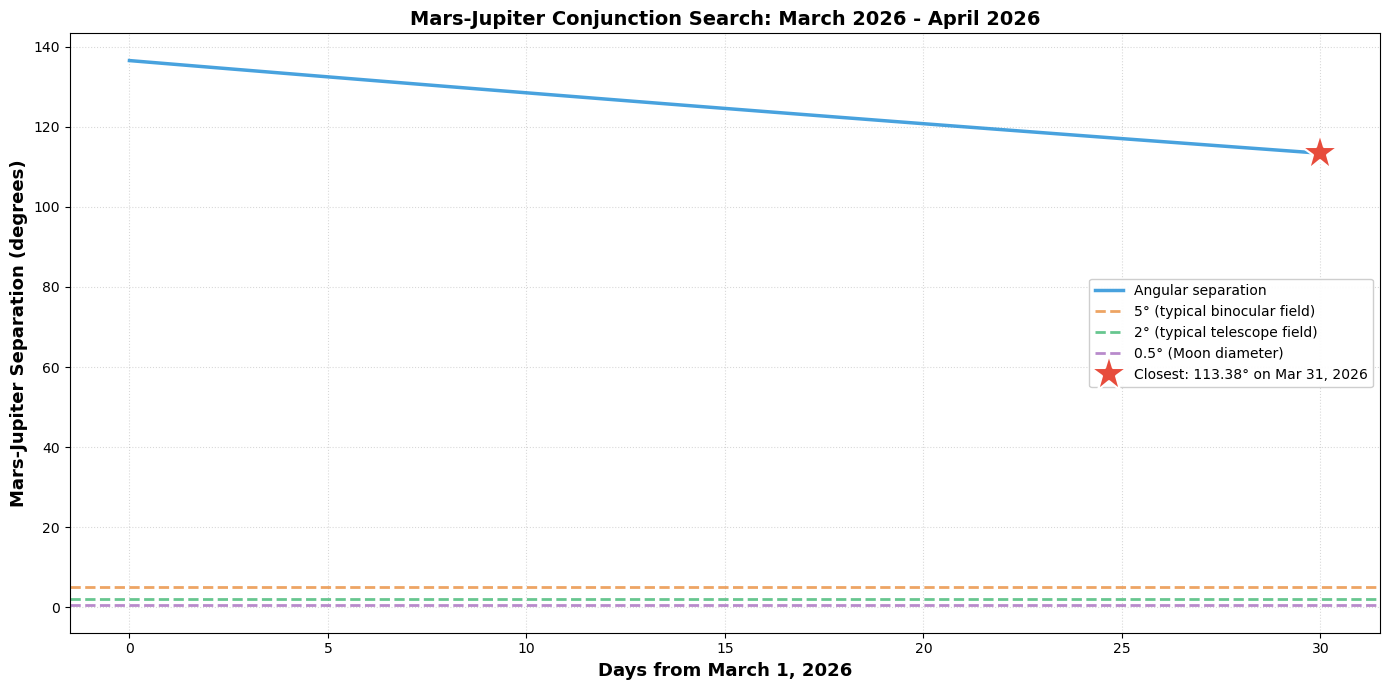

In [17]:
#CONJUNCTIONS AND SEPARATIONS!!!!!
search_days = np.arange(0, 31)  # Approximately 18 months
times_search = ts.utc(2026, 3, 1 + search_days)

print(f"Searching for Mars-Jupiter conjunctions...")
print(f"Period: {times_search[0].utc_strftime('%Y-%m-%d')} to {times_search[-1].utc_strftime('%Y-%m-%d')}")
print(f"Computing separations at {len(times_search)} daily intervals...")

mars_positions = earth.at(times_search).observe(bodies['mars']).apparent()
jupiter_positions = earth.at(times_search).observe(bodies['jupiter']).apparent()

# Calculate all separations at once
separations = mars_positions.separation_from(jupiter_positions).degrees

print(f"\nSeparation analysis:")
print(f"  Minimum: {np.min(separations):.2f}°")
print(f"  Maximum: {np.max(separations):.2f}°")
print(f"  Mean: {np.mean(separations):.2f}°")

close_threshold = 10.0  # degrees
close_approaches = np.where(separations < close_threshold)[0]

if len(close_approaches) > 0:
    print(f"\nFound {len(close_approaches)} days when Mars and Jupiter are within {close_threshold}°")
    
    # Find local minima (actual conjunctions) using vectorized comparison
    # A local minimum occurs where: sep[i] < sep[i-1] AND sep[i] < sep[i+1]
    # We use np.diff to find where the separation stops decreasing and starts increasing
    sep_diff = np.diff(separations)

    # Local minima occur where the derivative changes from negative to positive
    is_local_min = (sep_diff[:-1] < 0) & (sep_diff[1:] > 0)

    # Add 1 to indices because diff reduces array length
    potential_conjunctions = np.where(is_local_min)[0] + 1
    
    # Filter to only those below our threshold
    conjunctions = potential_conjunctions[separations[potential_conjunctions] < close_threshold]
    
    print(f"\nIdentified {len(conjunctions)} conjunction(s):\n")
    print("Date                Separation    Comment")
    print("=" * 65)
    
    for idx in conjunctions:
        date_str = times_search[idx].utc_strftime('%Y-%m-%d')
        sep = separations[idx]
        
        if sep < 2:
            comment = "Very close! Visible in telescope field"
        elif sep < 5:
            comment = "Close! Visible together in binoculars"
        elif sep < 10:
            comment = "Moderately close, wide field view"
        else:
            comment = ""
        
        print(f"{date_str:20s}{sep:6.2f}°        {comment}")
    
    # Find and highlight the closest approach
    closest_idx = np.argmin(separations)
    closest_date = times_search[closest_idx].utc_strftime('%Y-%m-%d')
    closest_sep = separations[closest_idx]
    
    print("\n" + "=" * 65)
    print(f"CLOSEST APPROACH: {closest_date}")
    print(f"Separation: {closest_sep:.3f}° ({closest_sep * 60:.1f} arcminutes)")
    print(f"For reference: Moon diameter is ~0.5° (30 arcminutes)")
else:
    print(f"\nNo close approaches found (all separations > {close_threshold}°)")

plt.figure(figsize=(14, 7))

# Plot separation over time
plt.plot(search_days, separations, color='#3498DB', linewidth=2.5, 
         label='Angular separation', alpha=0.9)

# Add reference lines for field of view sizes
plt.axhline(5, color='#E67E22', linestyle='--', alpha=0.7, linewidth=2, 
            label='5° (typical binocular field)')
plt.axhline(2, color='#27AE60', linestyle='--', alpha=0.7, linewidth=2, 
            label='2° (typical telescope field)')
plt.axhline(0.5, color='#9B59B6', linestyle='--', alpha=0.7, linewidth=2, 
            label='0.5° (Moon diameter)')

# Mark the closest approach
closest_idx = np.argmin(separations)
plt.plot(search_days[closest_idx], separations[closest_idx], '*', 
         color='#E74C3C', markersize=28, 
         label=f'Closest: {separations[closest_idx]:.2f}° on {times_search[closest_idx].utc_strftime("%b %d, %Y")}',
         markeredgecolor='white', markeredgewidth=1.5, zorder=5)

plt.xlabel('Days from March 1, 2026', fontsize=13, fontweight='bold')
plt.ylabel('Mars-Jupiter Separation (degrees)', fontsize=13, fontweight='bold')
plt.title('Mars-Jupiter Conjunction Search: March 2026 - April 2026', 
          fontsize=14, fontweight='bold')
plt.legend(fontsize=10, loc='best', framealpha=0.95)
plt.grid(alpha=0.3, linestyle=':', color='gray')
plt.tight_layout()
plt.show()